In [1]:
import pandas as pd
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
print(df.shape)
print(df.isnull().sum().sum())

(1470, 35)
0


In [3]:
print(df["Attrition"].value_counts())


Attrition
No     1233
Yes     237
Name: count, dtype: int64


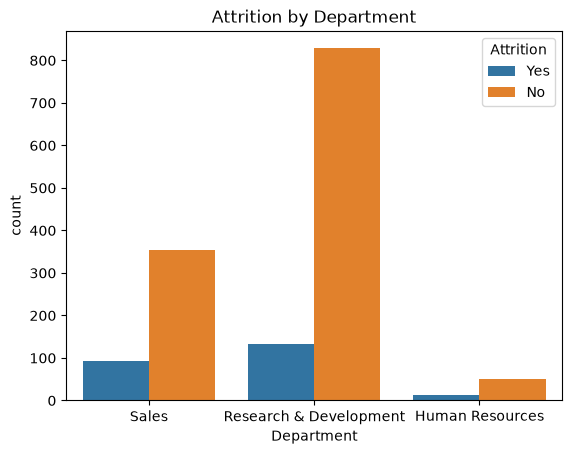

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="Department", hue="Attrition")
plt.title("Attrition by Department")
plt.show()

In [5]:
rate = df.groupby("Department")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)
print(rate.round(1))

Department
Human Resources           19.0
Research & Development    13.8
Sales                     20.6
Name: Attrition, dtype: float64


In [6]:
rate = df.groupby("OverTime")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)
print(rate.round(1))

OverTime
No     10.4
Yes    30.5
Name: Attrition, dtype: float64


In [7]:
print(df.groupby("Attrition")["MonthlyIncome"].mean().round(0))

Attrition
No     6833.0
Yes    4787.0
Name: MonthlyIncome, dtype: float64


In [8]:
df_model = df.drop(["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"], axis=1)
df_model["Attrition"] = df_model["Attrition"].map({"Yes": 1, "No": 0})
df_model = pd.get_dummies(df_model, drop_first=True)
print(df_model.shape)

(1470, 45)


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

X = df_model.drop("Attrition", axis=1)
y = df_model["Attrition"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_s, y_train)
pred = model.predict(X_test_s)
print(accuracy_score(y_test, pred))

0.8605442176870748


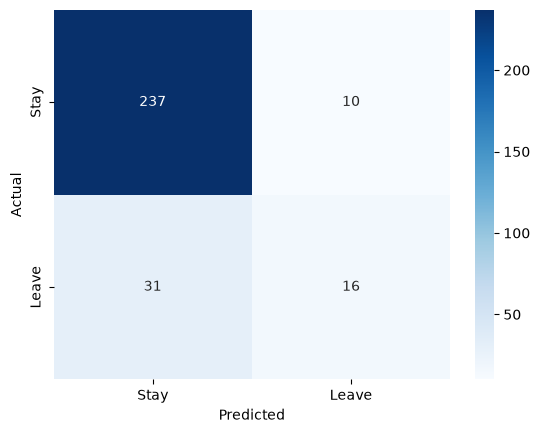

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



In [10]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Stay", "Leave"], yticklabels=["Stay", "Leave"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, pred))

Background dataset has 1176 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1176 when initializing the masker.


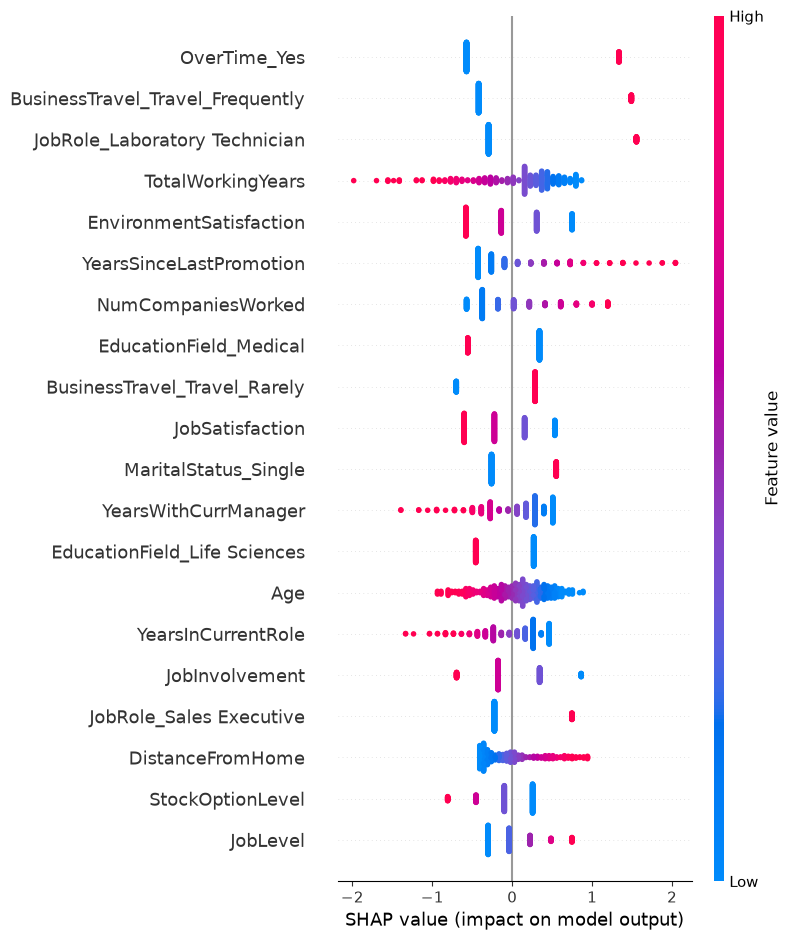

In [11]:
import shap

X_test_df = pd.DataFrame(X_test_s, columns=X.columns)
explainer = shap.LinearExplainer(model, X_train_s)
shap_values = explainer.shap_values(X_test_df)
shap.summary_plot(shap_values, X_test_df)

In [12]:
df["Leave_Probability"] = model.predict_proba(scaler.transform(X))[:, 1].round(3)
df.to_csv("hr_data_for_powerbi.csv", index=False)
print("Saved")

Saved


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(df.shape)

(1470, 35)


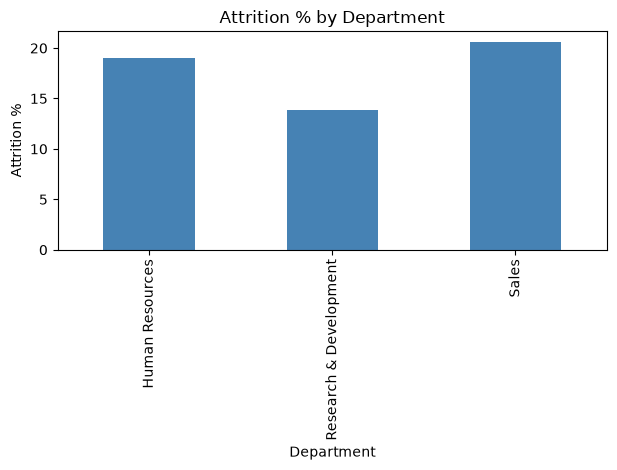

In [4]:
dept = df.groupby("Department")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)
dept.plot(kind="bar", color="steelblue")
plt.title("Attrition % by Department")
plt.ylabel("Attrition %")
plt.tight_layout()
plt.savefig("chart1_department.png", dpi=150)
plt.show()

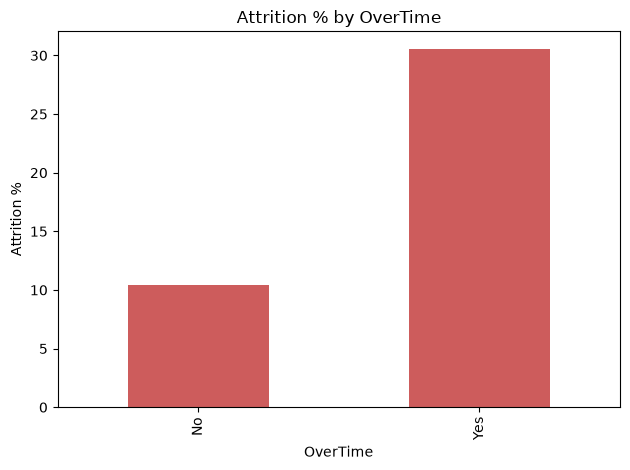

In [5]:
ot = df.groupby("OverTime")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)
ot.plot(kind="bar", color="indianred")
plt.title("Attrition % by OverTime")
plt.ylabel("Attrition %")
plt.tight_layout()
plt.savefig("chart2_overtime.png", dpi=150)
plt.show()

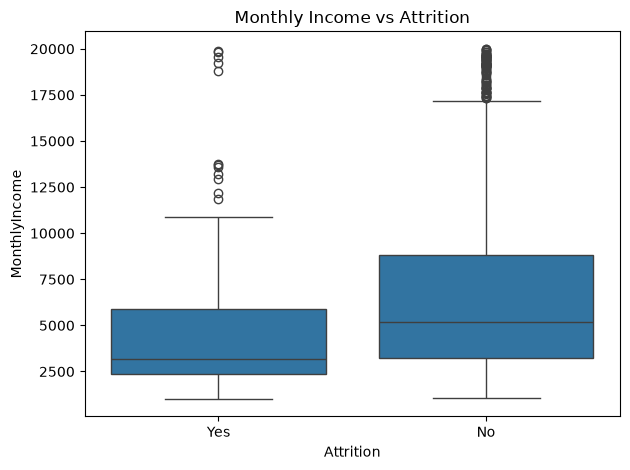

In [6]:
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome")
plt.title("Monthly Income vs Attrition")
plt.tight_layout()
plt.savefig("chart3_income.png", dpi=150)
plt.show()

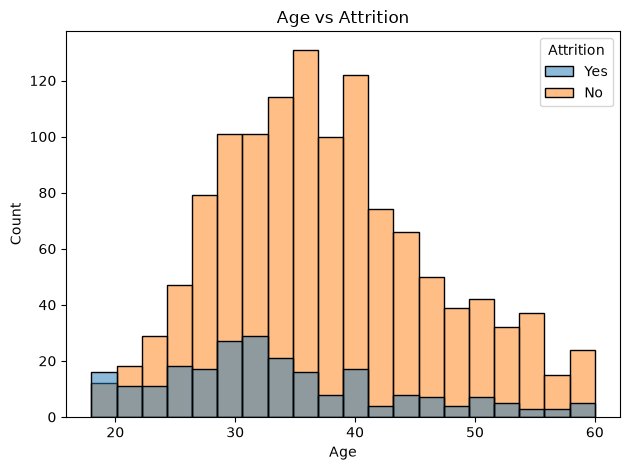

In [7]:
sns.histplot(data=df, x="Age", hue="Attrition", bins=20)
plt.title("Age vs Attrition")
plt.tight_layout()
plt.savefig("chart4_age.png", dpi=150)
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

df_model = df.drop(["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"], axis=1)
df_model["Attrition"] = df_model["Attrition"].map({"Yes": 1, "No": 0})
df_model = pd.get_dummies(df_model, drop_first=True)

X = df_model.drop("Attrition", axis=1)
y = df_model["Attrition"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_s, y_train)
pred = model.predict(X_test_s)

print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.8605442176870748
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



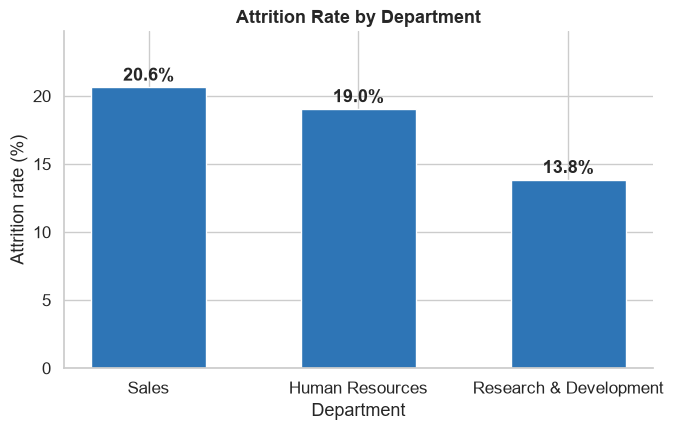

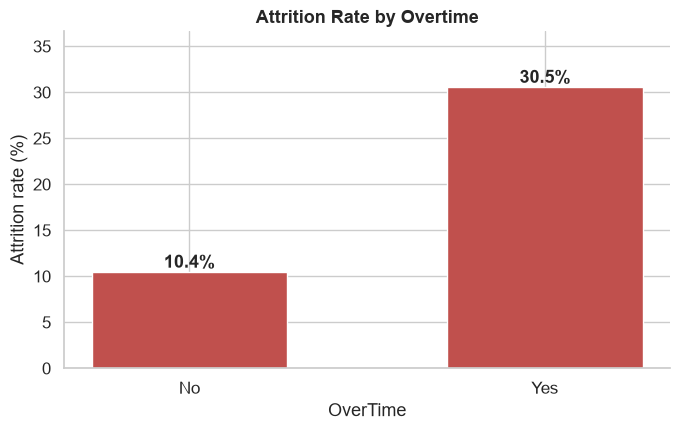

C:\Users\MINNU\AppData\Local\Temp\ipykernel_19356\2633404989.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", order=["Yes", "No"],


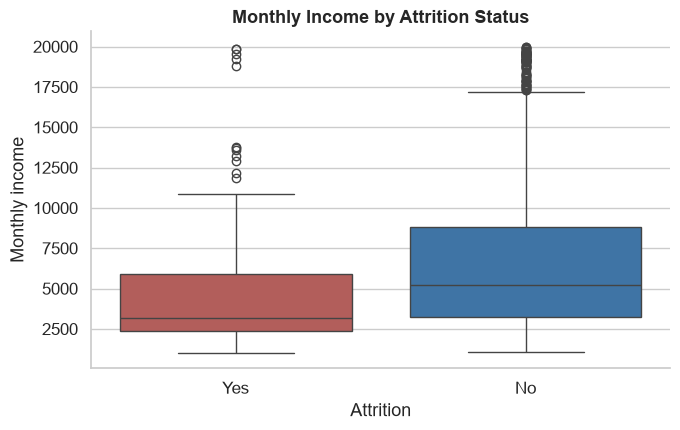

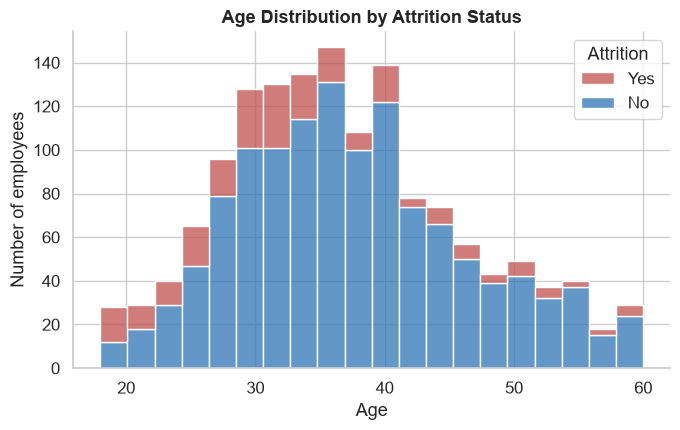

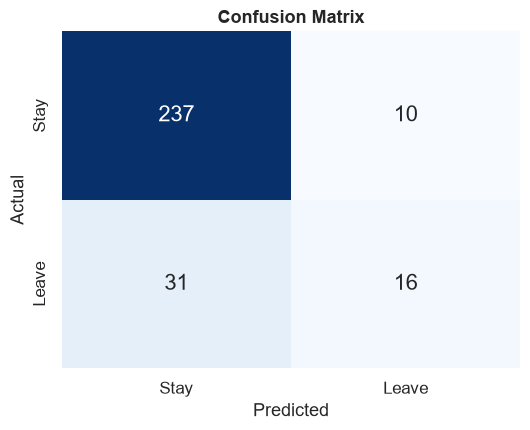

Background dataset has 1176 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1176 when initializing the masker.


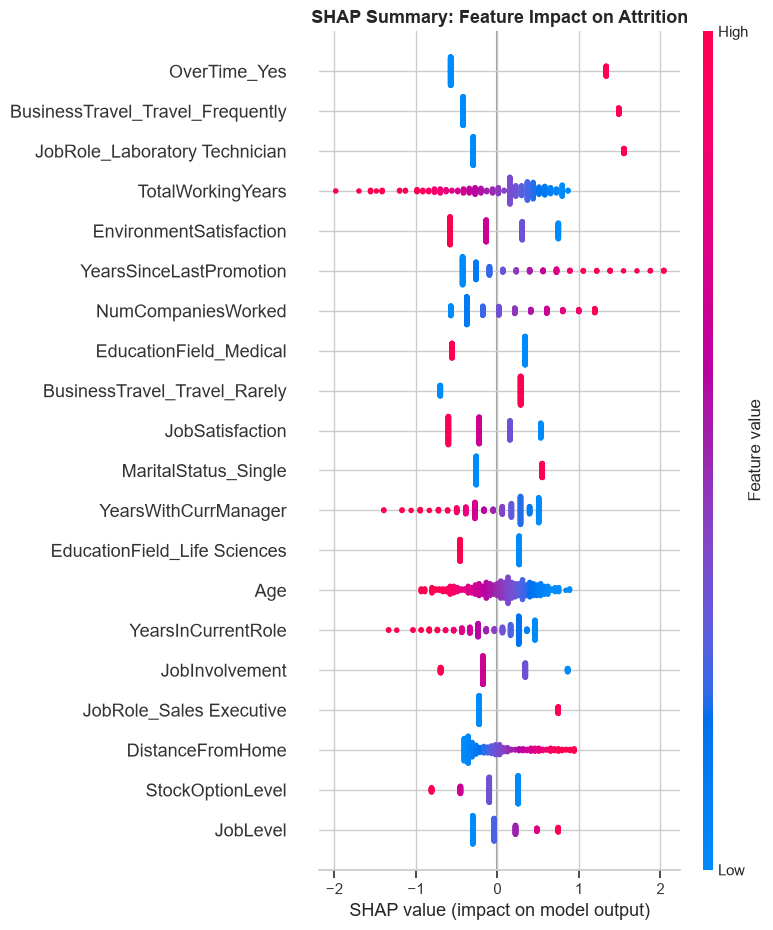

Done. 6 chart files saved in your project folder.


In [10]:
# Paste this into a NEW cell at the bottom of attrition_analysis.ipynb and run it.
# It saves clean, high-resolution charts (300 dpi) into your hr-attrition-project folder.
# Needs the variables already in your notebook: df, X_train, X_train_s, X_test_s, y_test, pred, model
 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
 
sns.set_theme(style="whitegrid", font_scale=1.1)
DPI = 300
 
def save(name):
    plt.tight_layout()
    plt.savefig(name, dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close()
 
def rate_chart(col, title, fname, color, order=None):
    rate = df.groupby(col)["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)
    if order:
        rate = rate.reindex(order)
    else:
        rate = rate.sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(7, 4.5))
    bars = ax.bar(rate.index, rate.values, color=color, width=0.55)
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5,
                f"{b.get_height():.1f}%", ha="center", fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Attrition rate (%)")
    ax.set_xlabel(col)
    ax.set_ylim(0, rate.max() * 1.2)
    sns.despine()
    save(fname)
 
# Chart 1: attrition by department
rate_chart("Department", "Attrition Rate by Department", "chart1_department.png", "#2E75B6")
 
# Chart 2: attrition by overtime
rate_chart("OverTime", "Attrition Rate by Overtime", "chart2_overtime.png", "#C0504D", order=["No", "Yes"])
 
# Chart 3: monthly income vs attrition
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", order=["Yes", "No"],
            palette=["#C0504D", "#2E75B6"], ax=ax)
ax.set_title("Monthly Income by Attrition Status", fontweight="bold")
ax.set_ylabel("Monthly income")
sns.despine()
save("chart3_income.png")
 
# Chart 4: age vs attrition
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(data=df, x="Age", hue="Attrition", multiple="stack", bins=20,
             palette={"Yes": "#C0504D", "No": "#2E75B6"}, ax=ax)
ax.set_title("Age Distribution by Attrition Status", fontweight="bold")
ax.set_ylabel("Number of employees")
sns.despine()
save("chart4_age.png")
 
# Chart 5: confusion matrix
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, annot_kws={"size": 16},
            xticklabels=["Stay", "Leave"], yticklabels=["Stay", "Leave"], ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix", fontweight="bold")
save("chart5_confusion_matrix.png")
 
# Chart 6: SHAP summary plot (run `pip install shap` first if needed)
import shap
cols = list(X_train.columns)
explainer = shap.Explainer(model, X_train_s)
sv = explainer(X_test_s)
plt.figure(figsize=(9, 8))
shap.summary_plot(sv.values, X_test_s, feature_names=cols, max_display=20, show=False)
plt.title("SHAP Summary: Feature Impact on Attrition", fontweight="bold")
save("chart6_shap.png")
 
print("Done. 6 chart files saved in your project folder.")
 

In [ ]:
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

chart_files = [
    "chart1_department.png",
    "chart2_overtime.png",
    "chart3_income.png",
    "chart4_age.png",
    "chart5_confusion_matrix.png",
    "chart6_shap.png",
]
missing_files = [name for name in chart_files if not Path(name).is_file()]
if missing_files:
    raise FileNotFoundError(
        "Run the chart-generation cell first. Missing: " + ", ".join(missing_files)
    )

pdf_path = Path.cwd() / "attrition_charts.pdf"
with PdfPages(pdf_path) as pdf:
    for chart_file in chart_files:
        image = mpimg.imread(chart_file)
        height, width = image.shape[:2]
        fig, ax = plt.subplots(figsize=(width / 300, height / 300))
        ax.imshow(image)
        ax.axis("off")
        fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
        pdf.savefig(fig, dpi=300, bbox_inches="tight", pad_inches=0)
        plt.close(fig)

print(f"Created PDF with {len(chart_files)} charts: {pdf_path}")